# Safety Helmet Detection — YOLOv8
**AIRI Team PITB — AI Internship Task 1**

Project: Detect **Helmet** and **No-helmet** in workplace/road images using YOLOv8.

**Note on classes:** The task brief's example for Option B lists Person, Helmet, and No-helmet,
but the minimum requirement (Section 3) is 2–5 classes. This project intentionally uses only
**2 classes — helmet, no_helmet** — since the goal is to classify head protection status,
not to detect people as a separate object. This choice is within the allowed range and should
be stated explicitly in the final report under Phase 1 (Problem Selection).

This notebook covers Phases 6–9 of the task: Colab setup, training, evaluation, and inference.
Run the cells top to bottom. Fill in the dataset path once your annotated dataset is in Drive.

## Phase 6 — Google Colab Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
!pip install -U ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 4.3 MB/s eta 0:00:00


In [ ]:
import torch
print("GPU Available:", torch.cuda.is_available())
!nvidia-smi

GPU Available: True
Sat Sep 19 12:00:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             12W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+---------------------------

In [ ]:
import shutil

dataset_path = "/content/drive/MyDrive/Helmet_Detection_YOLO/dataset_final"
zip_path = "/content/drive/MyDrive/Helmet_Detection_YOLO/dataset_final"

shutil.make_archive(
    zip_path,
    "zip",
    dataset_path
)

print("ZIP created:")
print(zip_path + ".zip")

ZIP created:
/content/drive/MyDrive/Helmet_Detection_YOLO/dataset_final.zip


In [27]:
import shutil, os

os.makedirs("/content/drive/MyDrive/Helmet_Detection_YOLO/models", exist_ok=True)
shutil.copy(
    "/content/runs/detect/train/weights/best.pt",
    "/content/drive/MyDrive/Helmet_Detection_YOLO/models/best.pt"
)
print("best.pt saved to Drive!")

best.pt saved to Drive!


In [3]:
from pathlib import Path

base = Path("/content/drive/MyDrive/Helmet_Detection_YOLO")

for item in base.iterdir():
    print(item.name)

dataset
.venv
data.yaml
best.pt
new_dataset
dataset_v2
dataset_final
data_final.yaml
dataset_final.zip


## Phase 7 — Model Training (Final: dataset_433)

In [7]:
import zipfile
from pathlib import Path

zip_path = Path("/content/drive/MyDrive/object detection new.v1i.yolov8.zip")
extract_path = Path("/content/drive/MyDrive/Helmet_Detection_YOLO/dataset_433")

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted successfully!")
print("Location:", extract_path)

Extracted successfully!
Location: /content/drive/MyDrive/Helmet_Detection_YOLO/dataset_433


In [14]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="/content/drive/MyDrive/Helmet_Detection_YOLO/dataset_433/data.yaml",
    epochs=30,
    imgsz=640,
    batch=8,
    device="cpu"
)

Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Helmet_Detection_YOLO/dataset_433/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, 

In [15]:
test_results = model.val(
    data="/content/drive/MyDrive/Helmet_Detection_YOLO/dataset_433/data.yaml",
    split="test",
    imgsz=640,
    device="cpu"
)

Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 4.3±4.1 ms, read: 6.6±1.5 MB/s, size: 39.3 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/drive/MyDrive/Helmet_Detection_YOLO/dataset_433/test/labels... 42 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 42/42 67.2it/s 0.6s
val: New cache created: /content/drive/MyDrive/Helmet_Detection_YOLO/dataset_433/test/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 9, len(boxes) = 149. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R     

In [17]:
import shutil
from pathlib import Path

source = Path("/content/runs/detect/predict")
destination = Path("/content/drive/MyDrive/Helmet_Detection_YOLO/final_predictions_15")

destination.mkdir(parents=True, exist_ok=True)

images = sorted([
    p for p in source.iterdir()
    if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
])

for i, image in enumerate(images[:15], start=1):
    shutil.copy2(image, destination / f"prediction_{i:02d}{image.suffix}")

print(f"Saved {min(15, len(images))} prediction images.")
print(destination)

Saved 15 prediction images.
/content/drive/MyDrive/Helmet_Detection_YOLO/final_predictions_15


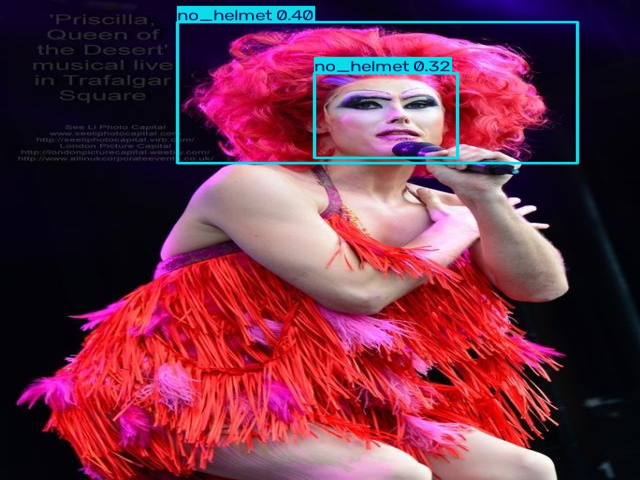

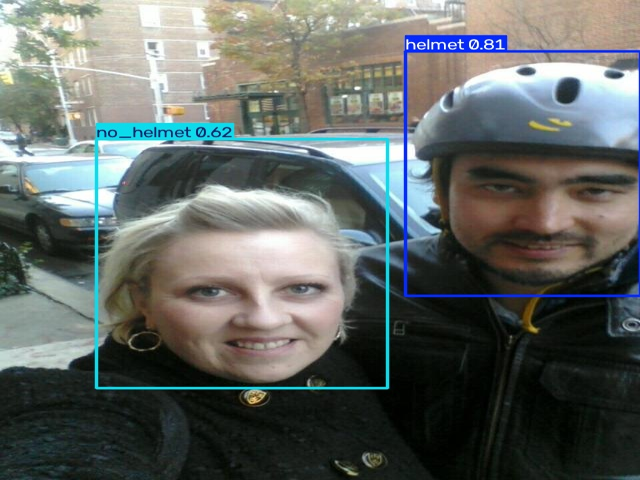

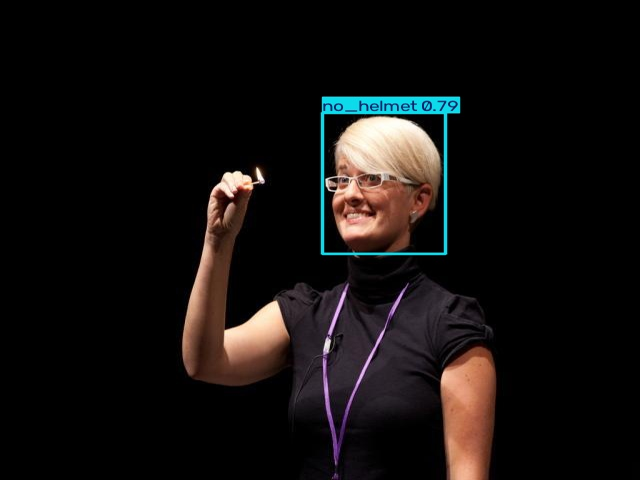

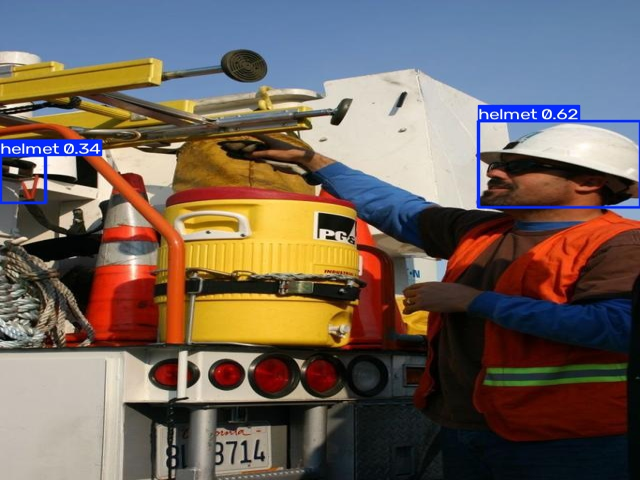

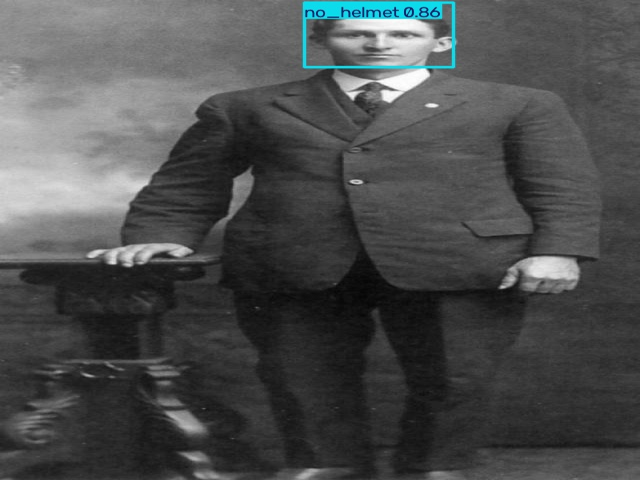

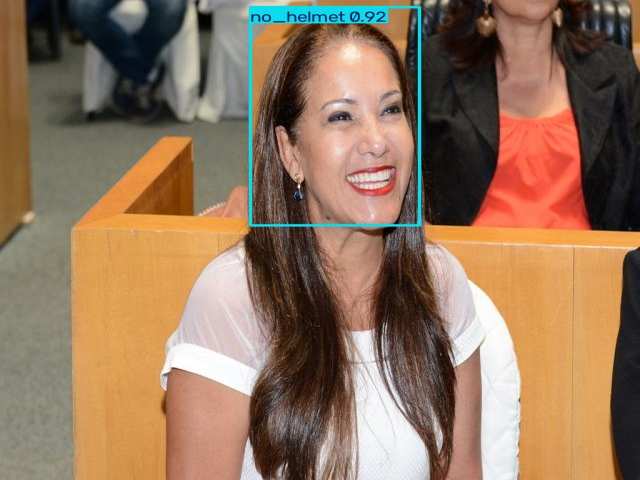

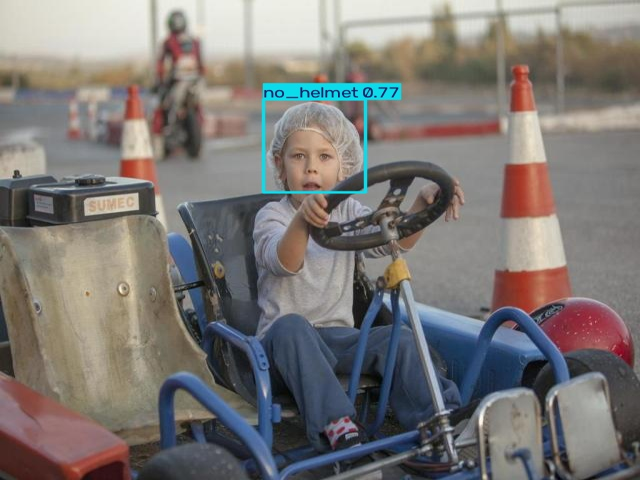

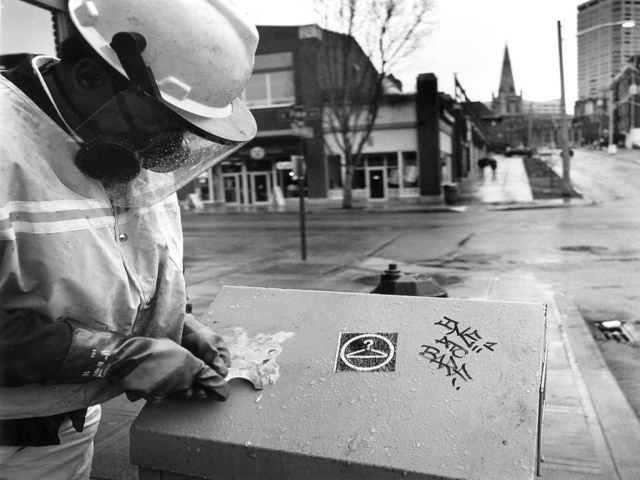

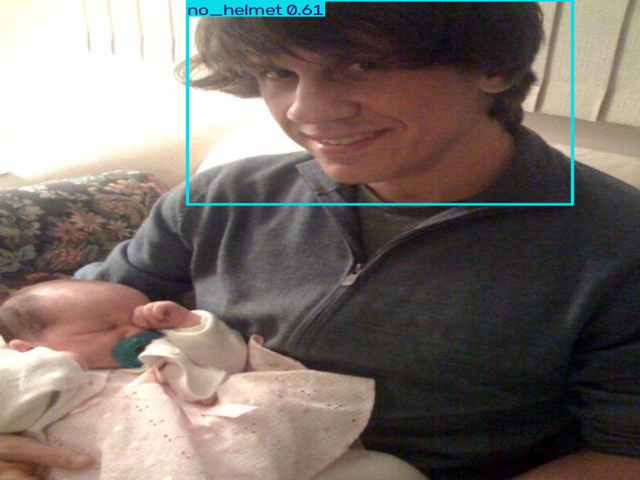

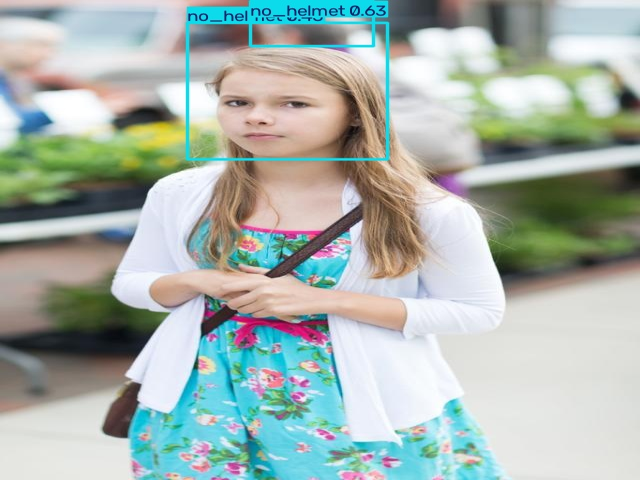

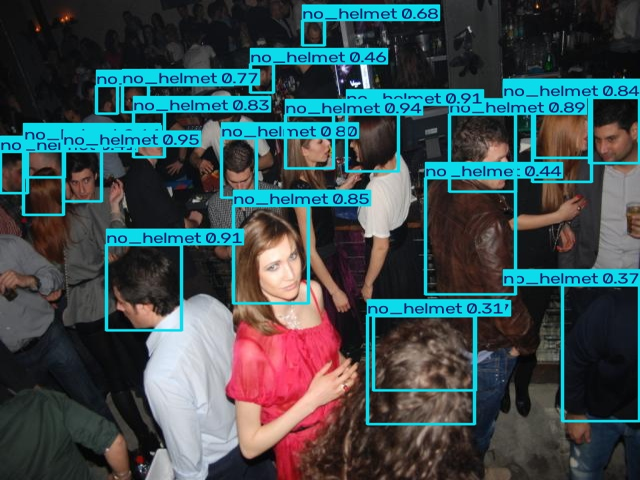

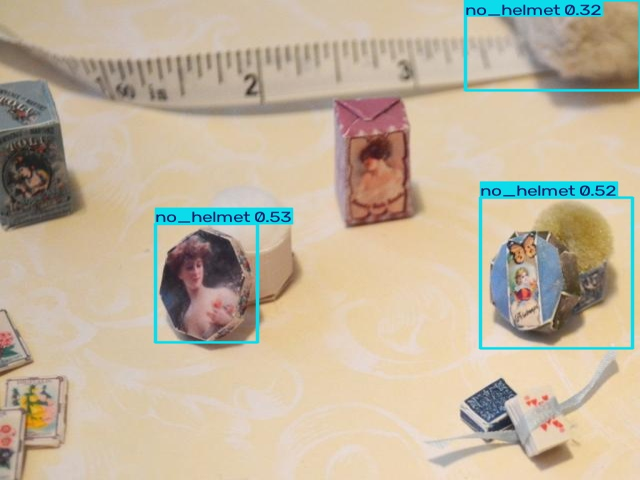

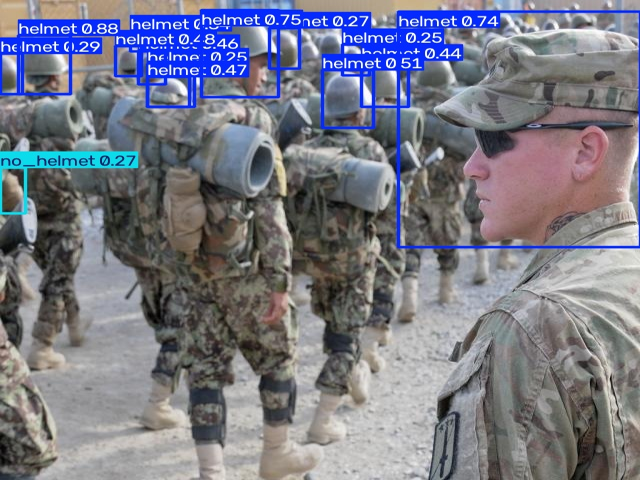

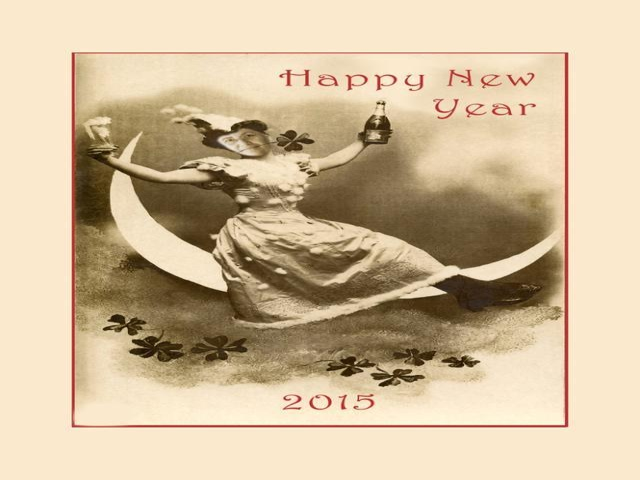

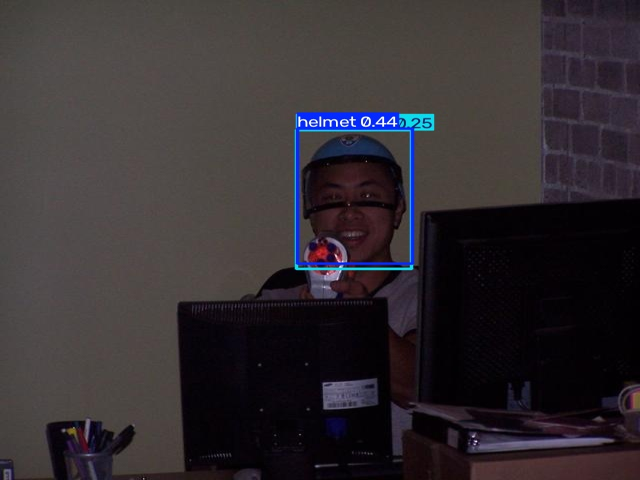

In [18]:
from IPython.display import display
from PIL import Image
from pathlib import Path

folder = Path("/content/drive/MyDrive/Helmet_Detection_YOLO/final_predictions_15")

for image_path in sorted(folder.glob("*")):
    display(Image.open(image_path).resize((640, 480)))

In [21]:
from pathlib import Path

pred_dir = Path("/content/runs/detect/predict")
gt_dir = Path("/content/drive/MyDrive/Helmet_Detection_YOLO/dataset_433/test/labels")

images = sorted([
    p for p in pred_dir.iterdir()
    if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
])[:15]

class_names = {
    0: "helmet",
    1: "no_helmet"
}

for i, img in enumerate(images, 1):
    gt_file = gt_dir / f"{img.stem}.txt"

    print(f"\n--- Prediction {i}: {img.name} ---")

    if gt_file.exists():
        gt_lines = gt_file.read_text().strip().splitlines()

        gt_classes = [
            class_names.get(int(line.split()[0]), line.split()[0])
            for line in gt_lines if line.strip()
        ]

        print("Ground truth:", gt_classes)
        print("GT objects:", len(gt_classes))
    else:
        print("Ground truth file NOT FOUND")

    pred_file = pred_dir / "labels" / f"{img.stem}.txt"

    if pred_file.exists():
        pred_lines = pred_file.read_text().strip().splitlines()

        print("Predicted:")

        for line in pred_lines:
            parts = line.split()

            if len(parts) >= 6:
                cls = class_names.get(int(parts[0]), parts[0])
                confidence = float(parts[5])
                print(f"  {cls} — confidence {confidence:.2f}")
    else:
        print("No prediction labels")


--- Prediction 1: 00090bdd55ec42c3_jpg.rf.19decdefbc458f0e338167b710353e4e.jpg ---
Ground truth: ['no_helmet']
GT objects: 1
Predicted:
  no_helmet — confidence 0.40
  no_helmet — confidence 0.32

--- Prediction 2: 1193f93d860edbd8_jpg.rf.9e9c09a7fb4fb81d5d00d457c05a3e7b.jpg ---
Ground truth: ['helmet', 'no_helmet']
GT objects: 2
Predicted:
  helmet — confidence 0.81
  no_helmet — confidence 0.62

--- Prediction 3: 22bb85e75bebce46_jpg.rf.706fa05b80f3c56447090f388f00d2ff.jpg ---
Ground truth: ['no_helmet']
GT objects: 1
Predicted:
  no_helmet — confidence 0.79

--- Prediction 4: 2e9553f7cb69b87e_jpg.rf.8e7b1304c0edbfdb0157e28ac265902d.jpg ---
Ground truth: ['helmet']
GT objects: 1
Predicted:
  helmet — confidence 0.62
  helmet — confidence 0.34

--- Prediction 5: 379ed4a1e3b91206_jpg.rf.f2e098359e46e299615454e476b49f62.jpg ---
Ground truth: ['no_helmet']
GT objects: 1
Predicted:
  no_helmet — confidence 0.86

--- Prediction 6: 45efd99a37a0c1d5_jpg.rf.055c33c4052c4c1158dd06067eea716c.j

In [22]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train/weights/best.pt")

model.val(
    data="/content/drive/MyDrive/Helmet_Detection_YOLO/dataset_433/data.yaml",
    split="val",
    imgsz=640,
    device="cpu",
    plots=True
)

Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.8±0.4 ms, read: 24.3±13.6 MB/s, size: 47.7 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/drive/MyDrive/Helmet_Detection_YOLO/dataset_433/valid/labels.cache... 88 images, 0 backgrounds, 2 corrupt: 100% ━━━━━━━━━━━━ 88/88 12.7Mit/s 0.0s
val: /content/drive/MyDrive/Helmet_Detection_YOLO/dataset_433/valid/images/new_65_jpg.rf.3964d23511220b17c4355d7e7f23cb46.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: /content/drive/MyDrive/Helmet_Detection_YOLO/dataset_433/valid/images/new_BikesHelmets213_png_jpg.rf.6838e153ea6aa4f352271231ba162daf.jpg: ignoring corrupt image/label: labels mix segment and detection rows
WARNING ⚠️ Box and segm

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d3eaeb9bb60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [23]:
import shutil
from pathlib import Path

source = Path("/content/runs/detect/val-2")
destination = Path("/content/drive/MyDrive/Helmet_Detection_YOLO/final_results")

destination.mkdir(parents=True, exist_ok=True)

for file in [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png"
]:
    src = source / file
    if src.exists():
        shutil.copy2(src, destination / file)
        print(f"Copied: {file}")

print("Done.")

Copied: confusion_matrix.png
Copied: confusion_matrix_normalized.png
Done.


In [24]:
import shutil
from pathlib import Path

source = Path("/content/runs/detect/train")
destination = Path("/content/drive/MyDrive/Helmet_Detection_YOLO/final_results")

destination.mkdir(parents=True, exist_ok=True)

for file in [
    "results.png",
    "results.csv"
]:
    src = source / file
    if src.exists():
        shutil.copy2(src, destination / file)
        print(f"Copied: {file}")

print("Done.")

Copied: results.png
Copied: results.csv
Done.


In [25]:
import os

folder = "/content/drive/MyDrive/Helmet_Detection_YOLO/final_results"

print(os.listdir(folder))

['confusion_matrix.png', 'confusion_matrix_normalized.png', 'results.png', 'results.csv']


In [26]:
import os

folder = "/content/drive/MyDrive/Helmet_Detection_YOLO/final_predictions_15"

files = os.listdir(folder)

print("Total files:", len(files))
print(files[:10])

Total files: 15
['prediction_01.jpg', 'prediction_02.jpg', 'prediction_03.jpg', 'prediction_04.jpg', 'prediction_05.jpg', 'prediction_06.jpg', 'prediction_07.jpg', 'prediction_08.jpg', 'prediction_09.jpg', 'prediction_10.jpg']


In [20]:
pred_results = model.predict(
    source="/content/drive/MyDrive/Helmet_Detection_YOLO/dataset_433/test/images",
    conf=0.25,
    imgsz=640,
    save=True,
    save_txt=True,
    save_conf=True,
    device="cpu"
)


image 1/42 /content/drive/MyDrive/Helmet_Detection_YOLO/dataset_433/test/images/00090bdd55ec42c3_jpg.rf.19decdefbc458f0e338167b710353e4e.jpg: 640x640 2 no_helmets, 179.4ms
image 2/42 /content/drive/MyDrive/Helmet_Detection_YOLO/dataset_433/test/images/1193f93d860edbd8_jpg.rf.9e9c09a7fb4fb81d5d00d457c05a3e7b.jpg: 640x640 1 helmet, 1 no_helmet, 176.7ms
image 3/42 /content/drive/MyDrive/Helmet_Detection_YOLO/dataset_433/test/images/22bb85e75bebce46_jpg.rf.706fa05b80f3c56447090f388f00d2ff.jpg: 640x640 1 no_helmet, 179.9ms
image 4/42 /content/drive/MyDrive/Helmet_Detection_YOLO/dataset_433/test/images/2e9553f7cb69b87e_jpg.rf.8e7b1304c0edbfdb0157e28ac265902d.jpg: 640x640 2 helmets, 173.6ms
image 5/42 /content/drive/MyDrive/Helmet_Detection_YOLO/dataset_433/test/images/379ed4a1e3b91206_jpg.rf.f2e098359e46e299615454e476b49f62.jpg: 640x640 1 no_helmet, 171.2ms
image 6/42 /content/drive/MyDrive/Helmet_Detection_YOLO/dataset_433/test/images/45efd99a37a0c1d5_jpg.rf.055c33c4052c4c1158dd06067eea716

In [29]:
import os
os.chdir("-helmet-detection-yolov8")
print(os.getcwd())

/content/-helmet-detection-yolov8


In [30]:
import shutil

# Notebook copy karein
shutil.copy(
    "/content/drive/MyDrive/Helmet_Detection_YOLO/training_notebook.ipynb",
    "/content/-helmet-detection-yolov8/training_notebook.ipynb"
)

# data.yaml copy karein
shutil.copy(
    "/content/drive/MyDrive/Helmet_Detection_YOLO/dataset_433/data.yaml",
    "/content/-helmet-detection-yolov8/data.yaml"
)

# Results folder copy karein
shutil.copytree(
    "/content/drive/MyDrive/Helmet_Detection_YOLO/final_results",
    "/content/-helmet-detection-yolov8/final_results"
)

# Prediction images copy karein
shutil.copytree(
    "/content/drive/MyDrive/Helmet_Detection_YOLO/final_predictions_15",
    "/content/-helmet-detection-yolov8/final_predictions_15"
)

print("Files copied successfully!")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Helmet_Detection_YOLO/training_notebook.ipynb'

In [31]:
import os

base = "/content/drive/MyDrive/Helmet_Detection_YOLO"
print(os.listdir(base))

['dataset', '.venv', 'data.yaml', 'best.pt', 'new_dataset', 'dataset_v2', 'dataset_final', 'data_final.yaml', 'dataset_final.zip', 'dataset_433', 'final_predictions_15', 'final_results', 'models']


## (Optional) Video Inference

In [ ]:
# Uncomment and set a video path if you're doing optional video inference
# video_results = inference_model.predict(
#     source="/content/drive/MyDrive/cv_project/sample_video.mp4",
#     conf=0.35,
#     save=True,
#     project="/content/drive/MyDrive/cv_project/outputs/predictions",
#     name="video_predictions"
# )

## Phase 10 — Error Analysis

Manually review at least 10 incorrect/weak predictions from the `test_predictions` folder above,
then fill this table (also copy it into your final report):

| Image | Actual Object | Model Prediction | Error Type | Possible Reason |
|---|---|---|---|---|
| image_01.jpg | helmet | not detected | False negative | Small object |
| image_02.jpg | no_helmet | helmet | Wrong class | Similar appearance |
| ... | | | | |

**Suggested improvements (pick at least 3):**
1. Add more images for the weakest class
2. Improve annotation quality / consistency
3. Add more low-light / occluded examples
4. Train for more epochs or try YOLOv8s
5. Balance the dataset across classes